In [4]:
import os
import torch
import librosa
import numpy as np
from glob import glob
from transformers import Wav2Vec2Model

/Users/adithyanv/Documents/SpeakEasy/speakeasy_env/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
BASE_DIR = "/Users/adithyanv/Documents/SpeakEasy"
SYNTH_DIR = os.path.join(BASE_DIR, "Data/Dysarthric_Dataset_Synthetic copy")
REAL_DIR = os.path.join(BASE_DIR, "Data/Dysarthric_Dataset_Realpatient_PreProcessed copy")
CHECKPOINT_PATH = os.path.join(BASE_DIR, "checkpoints/model_synthetic.pt")
print("Synthetic path exists:", os.path.exists(SYNTH_DIR))
print("Real path exists:", os.path.exists(REAL_DIR))
print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

Synthetic path exists: True
Real path exists: True
Checkpoint exists: True


In [6]:
COMMANDS = [
    "bright_light",
    "call_help",
    "call_home",
    "dim_light",
    "fan_off",
    "fan_on",
    "light_off",
    "light_on",
    "no",
    "yes"
]

label2id = {cmd: i for i, cmd in enumerate(COMMANDS)}
id2label = {i: cmd for cmd, i in label2id.items()}
NUM_LABELS = len(COMMANDS)

In [7]:
def load_audio(path):
    audio, _ = librosa.load(path, sr=16000)
    audio = audio / max(1e-9, np.max(np.abs(audio)))
    return audio

In [8]:
class Wav2Vec2Classifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = Wav2Vec2Model.from_pretrained("facebook/mms-1b-all")
        self.classifier = torch.nn.Linear(
            self.encoder.config.hidden_size,
            num_labels
        )

    def forward(self, input_values):
        outputs = self.encoder(input_values)
        hidden = outputs.last_hidden_state
        pooled = hidden.mean(dim=1)
        logits = self.classifier(pooled)
        return logits

In [9]:
print("========== PHASE ONE ==========")

========== PHASE ONE ==========


In [10]:
device = "cpu"  # Mac safe

model = Wav2Vec2Classifier(NUM_LABELS)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 9544.76it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


In [11]:
audio_paths = sorted(glob(f"{SYNTH_DIR}/*.wav"))
print("Total synthetic samples:", len(audio_paths))

sample_path = audio_paths[0]
audio = load_audio(sample_path)

x = torch.tensor(audio).unsqueeze(0)

with torch.no_grad():
    logits = model(x)
    pred = torch.argmax(logits, dim=1).item()

print("File:", os.path.basename(sample_path))
print("Predicted:", id2label[pred])

Total synthetic samples: 3360
File: bright_light_mild_0.wav
Predicted: bright_light


In [12]:
print("========== PHASE TWO  ==========")

========== PHASE TWO  ==========


In [13]:
def get_label_from_path(path):
    name = os.path.basename(path).replace(".wav", "")
    parts = name.split("_")
    return "_".join(parts[:-2])

In [14]:
from glob import glob

real_audio_paths = glob(f"{REAL_DIR}/**/*.wav", recursive=True)

print("Total real samples:", len(real_audio_paths))
print("Sample files:", real_audio_paths[:3])

Total real samples: 720
Sample files: ['/Users/adithyanv/Documents/SpeakEasy/Data/Dysarthric_Dataset_Realpatient_PreProcessed copy/fan_off_p2_3.wav', '/Users/adithyanv/Documents/SpeakEasy/Data/Dysarthric_Dataset_Realpatient_PreProcessed copy/bright_light_p2_1.wav', '/Users/adithyanv/Documents/SpeakEasy/Data/Dysarthric_Dataset_Realpatient_PreProcessed copy/yes_p15_2.wav']


In [15]:
from collections import Counter

real_labels = [get_label_from_path(p) for p in real_audio_paths]
counts = Counter(real_labels)

print("\nClass distribution:")
for cmd in COMMANDS:
    print(f"{cmd:15s} -> {counts.get(cmd, 0)}")


Class distribution:
bright_light    -> 65
call_help       -> 79
call_home       -> 45
dim_light       -> 69
fan_off         -> 79
fan_on          -> 83
light_off       -> 80
light_on        -> 80
no              -> 71
yes             -> 69


In [16]:
import torch

def predict_command_from_path(wav_path):
    audio = load_audio(wav_path)
    x = torch.tensor(audio, dtype=torch.float).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(x)
        pred_id = torch.argmax(out["logits"], dim=1).item()

    return id2label[pred_id]

In [17]:
model.eval()

Wav2Vec2Classifier(
  (encoder): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (pro

In [18]:
import os

def get_label_from_path(path):
    name = os.path.basename(path).replace(".wav", "")
    parts = name.split("_")
    return "_".join(parts[:-2])

In [19]:
import os

def get_label_from_path(path):
    name = os.path.basename(path).replace(".wav", "")
    parts = name.split("_")
    return "_".join(parts[:-2])

In [20]:
import torch
from torch.utils.data import Dataset

class CommandDataset(Dataset):
    def __init__(self, audio_paths):
        self.audio_paths = audio_paths

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        path = self.audio_paths[idx]

        audio = load_audio(path)
        label_name = get_label_from_path(path)
        label = label2id[label_name]

        return {
            "input_values": torch.tensor(audio, dtype=torch.float),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [21]:
def collate_fn(batch):
    input_values = [item["input_values"] for item in batch]
    labels = torch.stack([item["labels"] for item in batch])

    input_values = torch.nn.utils.rnn.pad_sequence(
        input_values,
        batch_first=True
    )

    return {
        "input_values": input_values,
        "labels": labels
    }

In [22]:
print("========== PHASE TWO ==========")

========== PHASE TWO ==========


In [23]:
device = "cpu"  # Mac safe

model = Wav2Vec2Classifier(NUM_LABELS)
model.load_state_dict(torch.load("checkpoints/model_synthetic.pt", map_location=device))
model.to(device)
model.train()

print("Synthetic model loaded.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 10155.00it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Synthetic model loaded.


In [24]:
from glob import glob

real_audio_paths = glob(f"{REAL_DIR}/**/*.wav", recursive=True)

print("Total real samples:", len(real_audio_paths))

Total real samples: 720


In [25]:
from sklearn.model_selection import train_test_split

real_train_paths, real_val_paths = train_test_split(
    real_audio_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train samples:", len(real_train_paths))
print("Val samples:", len(real_val_paths))



Train samples: 576
Val samples: 144


In [26]:
from torch.utils.data import DataLoader

real_train_ds = CommandDataset(real_train_paths)
real_val_ds = CommandDataset(real_val_paths)

real_train_loader = DataLoader(
    real_train_ds,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

real_val_loader = DataLoader(
    real_val_ds,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [27]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [28]:
for layer in model.encoder.encoder.layers[-4:]:
    for param in layer.parameters():
        param.requires_grad = True

In [29]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5
)

In [30]:
from tqdm import tqdm

In [27]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()

        x = batch["input_values"].to(device)
        y = batch["labels"].to(device)

        outputs = model(x)
        loss = torch.nn.functional.cross_entropy(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

       

In [28]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            x = batch["input_values"].to(device)
            y = batch["labels"].to(device)

            outputs = model(x)
            loss = torch.nn.functional.cross_entropy(outputs, y)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [31]:
device = "cpu"
model.to(device)

Wav2Vec2Classifier(
  (encoder): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (pro

In [32]:
print("========== PHASE TWO TRAINING A==========")

========== PHASE TWO TRAINING A==========


In [95]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, real_train_loader)
    val_loss, val_acc = evaluate(model, real_val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )

Epoch 1/10 | Train loss: 2.4383 | Val loss: 1.6643 | Val acc: 0.514


Epoch 2/10 | Train loss: 1.7998 | Val loss: 1.0341 | Val acc: 0.660


Epoch 3/10 | Train loss: 1.5002 | Val loss: 0.7499 | Val acc: 0.764


Epoch 4/10 | Train loss: 1.2710 | Val loss: 0.8887 | Val acc: 0.736


Epoch 5/10 | Train loss: 1.1789 | Val loss: 0.6721 | Val acc: 0.757


Epoch 6/10 | Train loss: 1.0840 | Val loss: 0.6595 | Val acc: 0.771


Epoch 7/10 | Train loss: 0.9861 | Val loss: 0.6978 | Val acc: 0.764


Epoch 8/10 | Train loss: 0.9772 | Val loss: 0.7072 | Val acc: 0.812


Epoch 9/10 | Train loss: 0.8104 | Val loss: 0.5150 | Val acc: 0.854


Epoch 10/10 | Train loss: 0.8193 | Val loss: 0.6830 | Val acc: 0.799


In [33]:
import os
os.makedirs("checkpoints", exist_ok=True)

torch.save(model.state_dict(), "checkpoints/model_real_85.pt")

print("Model saved as model_real_85.pt")

Model saved as model_real_85.pt


In [34]:
print("========== PHASE TWO TRAINING B ==========")

========== PHASE TWO TRAINING B ==========


In [35]:
device = "cpu"   # or "cuda" if using GPU
model = Wav2Vec2Classifier(NUM_LABELS)
model.load_state_dict(torch.load("checkpoints/model_real_85.pt", map_location=device))
model.to(device)

print("85% model reloaded.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 7613.88it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

In [ ]:
# Freeze everything first
for param in model.encoder.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer layers
for layer in model.encoder.encoder.layers[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6   # smaller than before
)

In [101]:
from tqdm import tqdm

EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, real_train_loader)
    val_loss, val_acc = evaluate(model, real_val_loader)

    print(
        f"\nFineTune Epoch {epoch+1}/5 | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/model_real_final.pt")
        print("✔ Improved model saved.")


FineTune Epoch 1/5 | Train loss: 0.5709 | Val loss: 0.4657 | Val acc: 0.854
✔ Improved model saved.



FineTune Epoch 2/5 | Train loss: 0.4918 | Val loss: 0.4674 | Val acc: 0.861
✔ Improved model saved.



FineTune Epoch 3/5 | Train loss: 0.5578 | Val loss: 0.4465 | Val acc: 0.861



FineTune Epoch 4/5 | Train loss: 0.4254 | Val loss: 0.4485 | Val acc: 0.875
✔ Improved model saved.



FineTune Epoch 5/5 | Train loss: 0.4818 | Val loss: 0.4470 | Val acc: 0.868


In [ ]:
device = "cpu"  # or "cuda" if using GPU

model = Wav2Vec2Classifier(NUM_LABELS)
model.load_state_dict(torch.load("checkpoints/model_real_final.pt", map_location=device))
model.to(device)
model.eval()

print("Model reloaded successfully.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 6850.73it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.bias   | UNEXPECTED |  | 
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model reloaded successfully.


In [37]:
pip install matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<Figure size 1000x800 with 0 Axes>

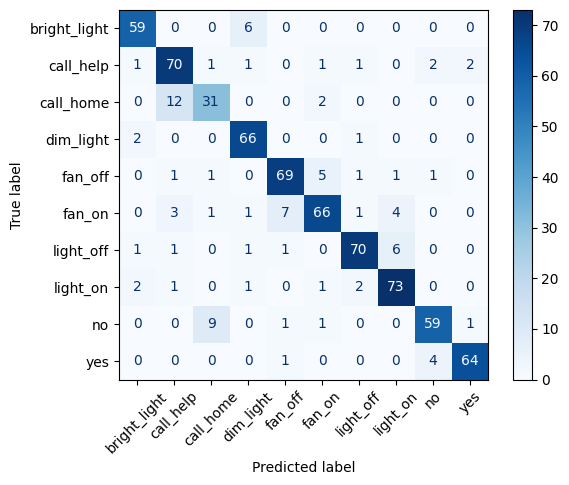

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

for p in real_audio_paths:
    true_label = get_label_from_path(p)
    pred_label = predict_command(p)

    all_labels.append(label2id[true_label])
    all_preds.append(label2id[pred_label])

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=COMMANDS)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

In [112]:
print("\nConfusion Matrix (rows = True, cols = Pred):\n")

print("      ", end="")
for cmd in COMMANDS:
    print(f"{cmd[:6]:>8}", end="")
print()

for i, row in enumerate(cm):
    print(f"{COMMANDS[i][:6]:>6}", end="")
    for val in row:
        print(f"{val:8}", end="")
    print()


Confusion Matrix (rows = True, cols = Pred):

        bright  call_h  call_h  dim_li  fan_of  fan_on  light_  light_      no     yes
bright      59       0       0       6       0       0       0       0       0       0
call_h       1      70       1       1       0       1       1       0       2       2
call_h       0      12      31       0       0       2       0       0       0       0
dim_li       2       0       0      66       0       0       1       0       0       0
fan_of       0       1       1       0      69       5       1       1       1       0
fan_on       0       3       1       1       7      66       1       4       0       0
light_       1       1       0       1       1       0      70       6       0       0
light_       2       1       0       1       0       1       2      73       0       0
    no       0       0       9       0       1       1       0       0      59       1
   yes       0       0       0       0       1       0       0       0       4     

In [36]:
import random
import os
from collections import defaultdict

# Group files by label
files_by_class = defaultdict(list)

for p in real_audio_paths:
    label = get_label_from_path(p)
    files_by_class[label].append(p)

print("Classes found:", list(files_by_class.keys()))

Classes found: ['fan_off', 'bright_light', 'yes', 'dim_light', 'light_on', 'fan_on', 'call_home', 'light_off', 'call_help', 'no']


In [ ]:
for cls in COMMANDS:
    print(f"\n===== CLASS: {cls} =====")

    samples = random.sample(files_by_class[cls], 
                            min(10, len(files_by_class[cls])))

    correct_count = 0

    for p in samples:
        pred = predict_command(p)
        true = cls

        status = "✅" if pred == true else "❌"
        if pred == true:
            correct_count += 1

        print(os.path.basename(p), 
              "| True:", true, 
              "| Pred:", pred, 
              status)

    print(f"Accuracy for {cls}: {correct_count}/{len(samples)}")


===== CLASS: bright_light =====
bright_light_p11_1.wav | True: bright_light | Pred: bright_light ✅
bright_light_p4_2.wav | True: bright_light | Pred: bright_light ✅
bright_light_p15_2.wav | True: bright_light | Pred: bright_light ✅
bright_light_p13_3.wav | True: bright_light | Pred: bright_light ✅
bright_light_p17_3.wav | True: bright_light | Pred: bright_light ✅
bright_light_p2_5.wav | True: bright_light | Pred: bright_light ✅
bright_light_p17_1.wav | True: bright_light | Pred: dim_light ❌
bright_light_p6_1.wav | True: bright_light | Pred: bright_light ✅
bright_light_p2_4.wav | True: bright_light | Pred: bright_light ✅
bright_light_p1_4.wav | True: bright_light | Pred: bright_light ✅
Accuracy for bright_light: 9/10

===== CLASS: call_help =====
call_help_p9_5.wav | True: call_help | Pred: call_help ✅
call_help_p19_3.wav | True: call_help | Pred: call_help ✅
call_help_p4_1.wav | True: call_help | Pred: call_help ✅
call_help_p7_2.wav | True: call_help | Pred: call_help ✅
call_help_p2_4

In [37]:
print("========== PHASE TWO TRAINING C ==========")

========== PHASE TWO TRAINING C ==========


In [38]:
import os
import torch
import librosa
import numpy as np
from glob import glob
from transformers import Wav2Vec2Model

In [39]:
import torch
from transformers import Wav2Vec2Model

class Wav2Vec2Classifier(torch.nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.encoder = Wav2Vec2Model.from_pretrained(
            "facebook/mms-1b-all"
        )
        self.classifier = torch.nn.Linear(
            self.encoder.config.hidden_size,
            num_labels
        )

    def forward(self, input_values):
        outputs = self.encoder(input_values)
        hidden = outputs.last_hidden_state
        pooled = hidden.mean(dim=1)
        logits = self.classifier(pooled)
        return logits

In [40]:
COMMANDS = [
    "bright_light",
    "call_help",
    "call_home",
    "dim_light",
    "fan_off",
    "fan_on",
    "light_off",
    "light_on",
    "no",
    "yes"
]

label2id = {cmd: i for i, cmd in enumerate(COMMANDS)}
id2label = {i: cmd for cmd, i in label2id.items()}
NUM_LABELS = len(COMMANDS)

In [41]:
device = "cpu"   # or "cuda" if using GPU

model = Wav2Vec2Classifier(NUM_LABELS)
model.load_state_dict(torch.load("checkpoints/model_real_85.pt", map_location=device))
model.to(device)
model.train()

print("Loaded 87% model.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 9108.55it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded 87% model.


In [42]:

from glob import glob
from sklearn.model_selection import train_test_split

real_audio_paths = glob(os.path.join(REAL_DIR, "*.wav"))

real_train_paths, real_val_paths = train_test_split(
    real_audio_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Original train:", len(real_train_paths))
print("Validation:", len(real_val_paths))

Original train: 576
Validation: 144


In [43]:
BASE_DIR = "/Users/adithyanv/Documents/SpeakEasy"
SYNTH_DIR = os.path.join(BASE_DIR, "Data/Dysarthric_Dataset_Synthetic copy")
REAL_DIR = os.path.join(BASE_DIR, "Data/Dysarthric_Dataset_Realpatient_PreProcessed copy")
CHECKPOINT_PATH = os.path.join(BASE_DIR, "checkpoints/model_synthetic.pt")
AUG_DIR = os.path.join(BASE_DIR,"Data/Augmented_Weak_Classes")


print("Synthetic path exists:", os.path.exists(SYNTH_DIR))
print("Real path exists:", os.path.exists(REAL_DIR))
print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))
print("Aug path exists:", os.path.exists(AUG_DIR))

Synthetic path exists: True
Real path exists: True
Checkpoint exists: True
Aug path exists: True


In [44]:
aug_paths = glob(os.path.join(AUG_DIR, "*.wav"))

real_train_paths = real_train_paths + aug_paths

print("Train after augmentation:", len(real_train_paths))

Train after augmentation: 783


In [45]:
def get_label_from_path(path):
    name = os.path.basename(path).replace(".wav", "")
    name = name.replace("_aug", "")

    parts = name.split("_")

    # yes / no single-word commands
    if parts[0] in ["no", "yes"]:
        return parts[0]

    # all two-word commands
    return "_".join(parts[:2])

In [46]:
real_train_ds = CommandDataset(real_train_paths)
real_val_ds = CommandDataset(real_val_paths)

real_train_loader = DataLoader(
    real_train_ds,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

real_val_loader = DataLoader(
    real_val_ds,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [47]:
# Freeze everything
for param in model.encoder.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers
for layer in model.encoder.encoder.layers[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

In [48]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-6
)

In [65]:
from tqdm import tqdm

EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, real_train_loader)
    val_loss, val_acc = evaluate(model, real_val_loader)

    print(
        f"\nAug FineTune Epoch {epoch+1}/5 | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/model_real_augmented.pt")
        print("✔ Improved model saved.")


Aug FineTune Epoch 1/5 | Train loss: 0.4775 | Val loss: 0.4481 | Val acc: 0.868
✔ Improved model saved.



Aug FineTune Epoch 2/5 | Train loss: 0.5210 | Val loss: 0.4411 | Val acc: 0.861



Aug FineTune Epoch 3/5 | Train loss: 0.5026 | Val loss: 0.4341 | Val acc: 0.875
✔ Improved model saved.



Aug FineTune Epoch 4/5 | Train loss: 0.4640 | Val loss: 0.4381 | Val acc: 0.861



Aug FineTune Epoch 5/5 | Train loss: 0.4726 | Val loss: 0.4343 | Val acc: 0.868


In [49]:
import random
import os
from collections import defaultdict

# Group files by label
files_by_class = defaultdict(list)

for p in real_audio_paths:
    label = get_label_from_path(p)
    files_by_class[label].append(p)

print("Classes found:", list(files_by_class.keys()))

Classes found: ['fan_off', 'bright_light', 'yes', 'dim_light', 'light_on', 'fan_on', 'call_home', 'light_off', 'call_help', 'no']


In [50]:
print("========== PHASE TWO TRAINING D ==========")

========== PHASE TWO TRAINING D ==========


In [51]:
# Freeze everything first
for param in model.encoder.parameters():
    param.requires_grad = False

# Unfreeze last 4 transformer layers
for layer in model.encoder.encoder.layers[-4:]:
    for param in layer.parameters():
        param.requires_grad = True

# Classifier should remain trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [53]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6
)

In [56]:
from tqdm import tqdm

EPOCHS = 5
best_val_acc = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, real_train_loader)
    val_loss, val_acc = evaluate(model, real_val_loader)

    print(
        f"\nDeep FineTune Epoch {epoch+1}/5 | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/model_real_90_push.pt")
        print("✔ Improved model saved.")

KeyboardInterrupt: 

In [54]:
print("========== PHASE TWO TRAINING E ==========")

========== PHASE TWO TRAINING E ==========


In [55]:
device = "cpu"   # or "cuda" if using GPU

model = Wav2Vec2Classifier(NUM_LABELS)
model.load_state_dict(torch.load("checkpoints/model_real_augmented.pt", map_location=device))
model.to(device)
model.train()

print("Loaded FINAL model.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 8004.40it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded FINAL model.


In [56]:
misclassified_paths = []

model.eval()

with torch.no_grad():
    for path in real_val_paths:

        audio = load_audio(path)
        x = torch.tensor(audio).unsqueeze(0).to(device)

        logits = model(x)   # directly get logits
        pred = torch.argmax(logits, dim=1).item()

        true_label = label2id[get_label_from_path(path)]

        if pred != true_label:
            misclassified_paths.append(path)

print("Total validation samples:", len(real_val_paths))
print("Misclassified samples:", len(misclassified_paths))

Total validation samples: 144
Misclassified samples: 17


In [57]:
val_loss, val_acc = evaluate(model, real_val_loader)
print("Validation accuracy:", val_acc)

NameError: name 'evaluate' is not defined

In [ ]:
hard_train_ds = CommandDataset(misclassified_paths)

hard_train_loader = DataLoader(
    hard_train_ds,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

print("Hard samples:", len(hard_train_ds))

Hard samples: 17


In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-6
)

In [76]:
from tqdm import tqdm
EPOCHS = 3
best_val_acc = 0.875  # current best

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, hard_train_loader)
    val_loss, val_acc = evaluate(model, real_val_loader)

    print(
        f"\nHard Mining Epoch {epoch+1}/3 | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/model_real_90_plus.pt")
        print("🔥 90% Push Model Saved.")


Hard Mining Epoch 1/3 | Train loss: 2.8007 | Val loss: 0.4603 | Val acc: 0.875



Hard Mining Epoch 2/3 | Train loss: 1.8955 | Val loss: 0.4304 | Val acc: 0.875



Hard Mining Epoch 3/3 | Train loss: 1.9938 | Val loss: 0.4499 | Val acc: 0.833


In [ ]:
print("========== PHASE TWO TRAINING F ==========")

========== PHASE TWO TRAINING F ==========


In [ ]:
import random
import librosa
import numpy as np

def load_audio(path, augment=False):
    audio, _ = librosa.load(path, sr=16000)

    if audio is None or len(audio) == 0:
        return np.zeros(16000)

    audio = audio / max(1e-9, np.max(np.abs(audio)))

    if augment:
        # Time stretch
        if random.random() < 0.5:
            rate = random.uniform(0.9, 1.1)
            audio = librosa.effects.time_stretch(audio, rate=rate)

        # Pitch shift
        if random.random() < 0.5:
            steps = random.uniform(-1, 1)
            audio = librosa.effects.pitch_shift(audio, sr=16000, n_steps=steps)

        # Add small Gaussian noise
        if random.random() < 0.5:
            noise = np.random.randn(len(audio)) * 0.003
            audio = audio + noise

    return audio

In [ ]:
class CommandDataset(Dataset):
    def __init__(self, audio_paths, augment=False):
        self.audio_paths = audio_paths
        self.augment = augment

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        path = self.audio_paths[idx]

        audio = load_audio(path, augment=self.augment)
        label_name = get_label_from_path(path)
        label = label2id[label_name]

        return {
            "input_values": torch.tensor(audio, dtype=torch.float),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
train_ds = CommandDataset(real_train_paths, augment=True)
val_ds = CommandDataset(real_val_paths, augment=False)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
# Freeze everything
for param in model.encoder.parameters():
    param.requires_grad = False

# Unfreeze last 4 transformer layers
for layer in model.encoder.encoder.layers[-4:]:
    for param in layer.parameters():
        param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6
)

In [94]:
from tqdm import tqdm

EPOCHS = 10
best_val_acc = 0.875  # your current best

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    print(
        f"\nAugmented Final Epoch {epoch+1}/10 | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "checkpoints/model_90_augmented.pt")
        print("🔥 New best model saved.")

    if val_acc < 0.82:
        print("⚠ Accuracy dropped too much. Stopping early.")
        break


Augmented Final Epoch 1/10 | Train loss: 0.9814 | Val loss: 0.4286 | Val acc: 0.833



Augmented Final Epoch 2/10 | Train loss: 0.8713 | Val loss: 0.4376 | Val acc: 0.826



Augmented Final Epoch 3/10 | Train loss: 0.9277 | Val loss: 0.3991 | Val acc: 0.840



Augmented Final Epoch 4/10 | Train loss: 0.8456 | Val loss: 0.4140 | Val acc: 0.840



Augmented Final Epoch 5/10 | Train loss: 0.8592 | Val loss: 0.3989 | Val acc: 0.840



Augmented Final Epoch 6/10 | Train loss: 0.7960 | Val loss: 0.3706 | Val acc: 0.861



Augmented Final Epoch 7/10 | Train loss: 0.7917 | Val loss: 0.3926 | Val acc: 0.833



Augmented Final Epoch 8/10 | Train loss: 0.8363 | Val loss: 0.3925 | Val acc: 0.833



Augmented Final Epoch 9/10 | Train loss: 0.8246 | Val loss: 0.3939 | Val acc: 0.833



Augmented Final Epoch 10/10 | Train loss: 0.7359 | Val loss: 0.3860 | Val acc: 0.875


In [58]:
print("========== PHASE THREE SAVING==========")

========== PHASE THREE SAVING==========


In [59]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Wav2Vec2Classifier(
  (encoder): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (pro

In [60]:
import os

os.makedirs("final_model", exist_ok=True)

torch.save(model.state_dict(), "final_model/model_final_875.pt")

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [61]:
test_model = Wav2Vec2Classifier(NUM_LABELS)
test_model.load_state_dict(torch.load("final_model/model_final_875.pt", map_location=device))
test_model.to(device)
test_model.eval()

print("✅ Model reloaded successfully.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 8326.23it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model reloaded successfully.


In [62]:
print("========== PHASE FOUR A EVALUATION ==========")

========== PHASE FOUR A EVALUATION ==========


In [68]:
from collections import defaultdict
import torch

model.eval()

class_correct = defaultdict(int)
class_total = defaultdict(int)

with torch.no_grad():
    for batch in val_loader:
        x = batch["input_values"].to(device)
        y = batch["labels"].to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        for true, pred in zip(y, preds):
            true_label = id2label[true.item()]
            class_total[true_label] += 1
            if true == pred:
                class_correct[true_label] += 1

print("\nPer-Class Accuracy:\n")

for cls in COMMANDS:
    acc = class_correct[cls] / class_total[cls]
    print(f"{cls:15s} → {acc:.3f}")


Per-Class Accuracy:

bright_light    → 0.812
call_help       → 0.941
call_home       → 0.727
dim_light       → 1.000
fan_off         → 0.842
fan_on          → 0.667
light_off       → 0.938
light_on        → 0.895
no              → 0.889
yes             → 1.000


In [212]:
import numpy as np

num_classes = len(COMMANDS)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

with torch.no_grad():
    for batch in val_loader:
        x = batch["input_values"].to(device)
        y = batch["labels"].to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        for true, pred in zip(y, preds):
            conf_matrix[true.item()][pred.item()] += 1

print("\nConfusion Matrix (Rows=True, Cols=Pred):\n")

header = "      " + " ".join([f"{c[:6]:>6}" for c in COMMANDS])
print(header)

for i, row in enumerate(conf_matrix):
    print(f"{COMMANDS[i][:6]:>6} " + " ".join([f"{x:6d}" for x in row]))


Confusion Matrix (Rows=True, Cols=Pred):

      bright call_h call_h dim_li fan_of fan_on light_ light_     no    yes
bright     13      0      0      2      0      0      1      0      0      0
call_h      0     16      0      0      0      1      0      0      0      0
call_h      0      2      8      0      1      0      0      0      0      0
dim_li      0      0      0     14      0      0      0      0      0      0
fan_of      0      0      1      0     16      0      2      0      0      0
fan_on      0      0      0      0      2      8      0      2      0      0
light_      0      0      0      0      0      0     15      1      0      0
light_      1      0      0      0      0      0      1     17      0      0
    no      0      0      0      0      0      0      1      0      8      0
   yes      0      0      0      0      0      0      0      0      0     11


In [63]:
print("========== PHASE FOUR B PREDICTION ==========")

========== PHASE FOUR B PREDICTION ==========


In [64]:
def predict_command(audio_path):
    model.eval()

    audio = load_audio(audio_path, augment=False)
    x = torch.tensor(audio).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    return id2label[pred]

In [75]:
import random
import os

print("\nRandom Validation Predictions:\n")

samples = random.sample(real_val_paths, 10)

for p in samples:
    true_label = get_label_from_path(p)
    pred_label = predict_command(p)
    print(f"{os.path.basename(p)} | True: {true_label} | Pred: {pred_label}")


Random Validation Predictions:

call_help_p10_4.wav | True: call_help | Pred: no
dim_light_p10_2.wav | True: dim_light | Pred: dim_light
fan_off_p2_5.wav | True: fan_off | Pred: fan_off
dim_light_p10_1.wav | True: dim_light | Pred: dim_light
fan_off_p1_3.wav | True: fan_off | Pred: fan_off
fan_off_p15_4.wav | True: fan_off | Pred: light_off
call_help_p11_1.wav | True: call_help | Pred: call_help
call_help_p16_3.wav | True: call_help | Pred: call_help
yes_p1_3.wav | True: yes | Pred: yes
bright_light_p19_1.wav | True: bright_light | Pred: bright_light


In [75]:
print("========== PHASE FOUR C AUDIO PREDICTION ==========")

========== PHASE FOUR C AUDIO PREDICTION ==========


In [65]:
pip install sounddevice soundfile

  Using cached sounddevice-0.5.5-py3-none-macosx_10_6_x86_64.macosx_10_6_universal2.whl.metadata (1.4 kB)
Using cached sounddevice-0.5.5-py3-none-macosx_10_6_x86_64.macosx_10_6_universal2.whl (108 kB)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [66]:
device = "cpu"   # or "cuda" if using GPU

test_model = Wav2Vec2Classifier(NUM_LABELS)
test_model.load_state_dict(torch.load("final_model/model_final_875.pt", map_location=device))
test_model.to(device)
test_model.eval()

print("✅ Model reloaded successfully.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 8513.62it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model reloaded successfully.


In [86]:
import sounddevice as sd
import numpy as np
import torch
import time

SAMPLE_RATE = 16000
DURATION = 3  # seconds

def record_audio():
    print("🎤 Recording... Speak now.")
    audio = sd.rec(int(DURATION * SAMPLE_RATE),
                   samplerate=SAMPLE_RATE,
                   channels=1)
    sd.wait()
    print("✅ Recording finished.")
    return audio.flatten()

def play_audio(audio_array):
    print("🔊 Playing back recorded audio...")
    sd.play(audio_array, SAMPLE_RATE)
    sd.wait()
    print("✅ Playback finished.")

def predict_from_audio_array(audio_array):
    model.eval()

    # Normalize
    audio_array = audio_array / max(1e-9, np.max(np.abs(audio_array)))

    x = torch.tensor(audio_array, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    return id2label[pred]

def live_predict():
    audio = record_audio()
    time.sleep(0.5)

    play_audio(audio)
    time.sleep(0.5)

    prediction = predict_from_audio_array(audio)

    print("\n🔮 Predicted Command:", prediction, "\n")

live_predict()

🎤 Recording... Speak now.
✅ Recording finished.
🔊 Playing back recorded audio...
✅ Playback finished.

🔮 Predicted Command: light_off 



In [67]:
print("========== PHASE FIVE FEEDBACK MODULE ==========")

========== PHASE FIVE FEEDBACK MODULE ==========


In [68]:
pip install pyttsx3

  Using cached pyttsx3-2.99-py3-none-any.whl.metadata (6.2 kB)
  Using cached pyobjc-12.1-py3-none-any.whl.metadata (26 kB)
  Using cached pyobjc_core-12.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (2.8 kB)
  Using cached pyobjc_framework_libdispatch-12.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (2.5 kB)
  Using cached pyobjc_framework_libxpc-12.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (2.5 kB)
  Using cached pyobjc_framework_accessibility-12.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (2.6 kB)
  Using cached pyobjc_framework_adservices-12.1-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached pyobjc_framework_adsupport-12.1-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached pyobjc_framework_apptrackingtransparency-12.1-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached pyobjc_framework_arkit-12.1-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached pyobjc_framework_audiovideobridging-12.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (2.5 kB)

In [69]:
import pyttsx3

engine = pyttsx3.init()

def speak(text):
    print("🔊 Speaking:", text)
    engine.say(text)
    engine.runAndWait()

In [70]:
import pyttsx3

engine = pyttsx3.init(driverName='nsss')
engine.say("Testing speech system.")
engine.runAndWait()

In [71]:
import numpy as np
import sounddevice as sd

def beep(duration=0.3, frequency=1000, sample_rate=16000):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    tone = 0.5 * np.sin(2 * np.pi * frequency * t)
    sd.play(tone, sample_rate)
    sd.wait()

In [76]:
import os
import time

SAMPLE_RATE = 16000
DURATION = 3  # seconds

def speak(text):
    print("🔊 Speaking:", text)
    os.system(f'say "{text}"')
    time.sleep(0.5)  # ensure speech finishes cleanly

def confirm_and_execute(max_attempts=3):

    attempts = 0

    while attempts < max_attempts:

        # ---- STEP 1: Record Command ----
        speak("Please say your command after the beep.")
        time.sleep(0.5)
        beep()

        command_audio = record_audio()
        command = predict_from_audio_array(command_audio)

        print("🔮 Predicted Command:", command)

        # ---- STEP 2: Confirm ----
        speak(f"I heard {command}. Please say yes to confirm or no to repeat.")
        time.sleep(1.0)  # give patient time before recording
        beep()

        confirm_audio = record_audio()
        response = predict_from_audio_array(confirm_audio)

        print("🧠 Confirmation Response:", response)

        # ---- STEP 3: Decision ----
        if response.lower() == "yes":
            speak(f"Confirmed. Executing {command}.")
            print("✅ EXECUTING:", command)
            return command

        elif response.lower() == "no":
            speak("Okay. Let us try again.")
            attempts += 1
            time.sleep(0.5)

        else:
            speak("I did not understand. Please say yes or no clearly.")
            attempts += 1
            time.sleep(0.5)
            beep()

    speak("Maximum attempts reached. Command cancelled.")
    print("❌ CANCELLED")
    return None

In [85]:
confirm_and_execute()

🔊 Speaking: Please say your command after the beep.
🎤 Recording... Speak now.
✅ Recording finished.
🔮 Predicted Command: call_help
🔊 Speaking: I heard call_help. Please say yes to confirm or no to repeat.
🎤 Recording... Speak now.
✅ Recording finished.
🧠 Confirmation Response: yes
🔊 Speaking: Confirmed. Executing call_help.
✅ EXECUTING: call_help


'call_help'

In [72]:
device = "cpu"   # or "cuda" if using GPU

test_model = Wav2Vec2Classifier(NUM_LABELS)
test_model.load_state_dict(torch.load("final_model/model_final_875.pt", map_location=device))
test_model.to(device)
test_model.eval()

print("✅ Model reloaded successfully.")

Loading weights: 100%|██████████| 1094/1094 [00:00<00:00, 6834.99it/s]
Wav2Vec2Model LOAD REPORT from: facebook/mms-1b-all
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model reloaded successfully.


In [73]:
import requests

BASE = "http://192.168.4.1"

def light_on():
    requests.get(f"{BASE}/light/on")

def light_off():
    requests.get(f"{BASE}/light/off")

def fan_on():
    requests.get(f"{BASE}/fan/on")

def fan_off():
    requests.get(f"{BASE}/fan/off")

def bright_light():
    requests.get(f"{BASE}/led/bright")

def dim_light():
    requests.get(f"{BASE}/led/dim")

def led_off():
    requests.get(f"{BASE}/led/off")

def call_help():
    requests.get(f"{BASE}/help")

def call_home():
    requests.get(f"{BASE}/home")

In [74]:
command_actions = {
    "light_on": light_on,
    "light_off": light_off,
    "fan_on": fan_on,
    "fan_off": fan_off,
    "bright_light": bright_light,
    "dim_light": dim_light,
    "call_help": call_help,
    "call_home": call_home
}

In [85]:
if response == "yes":
    speak(f"Executing {command}")
    print("Executing:", command)

    if command in command_actions:
        command_actions[command]()   # CALL ESP32 FUNCTION

return command

NameError: name 'response' is not defined

In [78]:
import requests

BASE = "http://192.168.4.1"

def light_on():
    requests.get(f"{BASE}/light/on")

In [79]:
def bright_light():
    requests.get(f"{BASE}/led/bright")

In [80]:
import os
import time
import requests

SAMPLE_RATE = 16000
DURATION = 3  # seconds

BASE = "http://192.168.4.1"

# -------- ESP32 COMMAND FUNCTIONS --------
def light_on():
    requests.get(f"{BASE}/light/on")

def light_off():
    requests.get(f"{BASE}/light/off")
    requests.get(f"{BASE}/led/off")


def fan_on():
    requests.get(f"{BASE}/fan/on")

def fan_off():
    requests.get(f"{BASE}/fan/off")

def bright_light():
    requests.get(f"{BASE}/led/bright")

def dim_light():
    requests.get(f"{BASE}/led/dim")

def call_help():
    requests.get(f"{BASE}/help")

def call_home():
    requests.get(f"{BASE}/home")


# -------- COMMAND → FUNCTION MAPPING --------
command_actions = {
    "light_on": light_on,
    "light_off": light_off,
    "fan_on": fan_on,
    "fan_off": fan_off,
    "bright_light": bright_light,
    "dim_light": dim_light,
    "led_off": led_off,
    "call_help": call_help,
    "call_home": call_home
}


# -------- SPEECH OUTPUT --------
def speak(text):
    print("🔊 Speaking:", text)
    os.system(f'say "{text}"')
    time.sleep(0.5)


# -------- MAIN CONFIRMATION SYSTEM --------
def confirm_and_execute(max_attempts=3):

    attempts = 0

    while attempts < max_attempts:

        # ---- STEP 1: Record Command ----
        speak("Please say your command after the beep.")
        time.sleep(0.5)
        beep()

        command_audio = record_audio()
        command = predict_from_audio_array(command_audio)

        print("🔮 Predicted Command:", command)

        # ---- STEP 2: Confirm ----
        speak(f"I heard {command}. Please say yes to confirm or no to repeat.")
        time.sleep(1.0)
        beep()

        confirm_audio = record_audio()
        response = predict_from_audio_array(confirm_audio)

        print("🧠 Confirmation Response:", response)

        # ---- STEP 3: Decision ----
        if response.lower() == "yes":

            speak(f"Confirmed. Executing {command}.")
            print("✅ EXECUTING:", command)

            # 🔥 SEND COMMAND TO ESP32
            if command in command_actions:
                command_actions[command]()
                print("📡 Command sent to ESP32")

            else:
                print("⚠️ Unknown command")

            return command

        elif response.lower() == "no":
            speak("Okay. Let us try again.")
            attempts += 1
            time.sleep(0.5)

        else:
            speak("I did not understand. Please say yes or no clearly.")
            attempts += 1
            time.sleep(0.5)
            beep()

    speak("Maximum attempts reached. Command cancelled.")
    print("❌ CANCELLED")
    return None

In [88]:
confirm_and_execute()

🔊 Speaking: Please say your command after the beep.
🎤 Recording... Speak now.
✅ Recording finished.
🔮 Predicted Command: call_help
🔊 Speaking: I heard call_help. Please say yes to confirm or no to repeat.
🎤 Recording... Speak now.
✅ Recording finished.
🧠 Confirmation Response: call_help
🔊 Speaking: I did not understand. Please say yes or no clearly.
🔊 Speaking: Please say your command after the beep.
🎤 Recording... Speak now.
✅ Recording finished.
🔮 Predicted Command: bright_light
🔊 Speaking: I heard bright_light. Please say yes to confirm or no to repeat.
🎤 Recording... Speak now.
✅ Recording finished.
🧠 Confirmation Response: dim_light
🔊 Speaking: I did not understand. Please say yes or no clearly.
🔊 Speaking: Please say your command after the beep.
🎤 Recording... Speak now.
✅ Recording finished.
🔮 Predicted Command: no
🔊 Speaking: I heard no. Please say yes to confirm or no to repeat.
🎤 Recording... Speak now.
✅ Recording finished.
🧠 Confirmation Response: no
🔊 Speaking: Okay. Let u

In [122]:
dim_light()

In [123]:
bright_light()

In [82]:
light_off()

In [138]:
light_on()

In [ ]:
call_help()

In [ ]:
call_home()

In [133]:
fan_on()

In [134]:
fan_off()

<Figure size 1000x800 with 0 Axes>

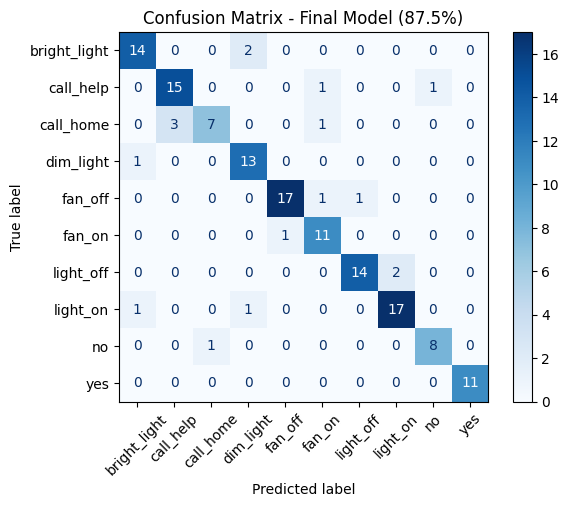

Validation Accuracy: 0.8819444444444444


In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

all_preds = []
all_labels = []

for p in real_val_paths:   # use validation set (important)

    true_label = get_label_from_path(p)
    audio = load_audio(p)

    x = torch.tensor(audio).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = test_model(x)

        if isinstance(outputs, dict):
            logits = outputs["logits"]
        else:
            logits = outputs

        pred_id = torch.argmax(logits, dim=1).item()

    all_labels.append(label2id[true_label])
    all_preds.append(pred_id)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=COMMANDS)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Final Model (87.5%)")
plt.show()

accuracy = sum([p==t for p,t in zip(all_preds, all_labels)]) / len(all_labels)
print("Validation Accuracy:", accuracy)

In [252]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jiwer]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [253]:
from jiwer import wer
import torch

all_preds_text = []
all_true_text = []

correct = 0

for p in real_val_paths:

    true_label = get_label_from_path(p)
    audio = load_audio(p)

    x = torch.tensor(audio).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = test_model(x)
        if isinstance(outputs, dict):
            logits = outputs["logits"]
        else:
            logits = outputs

        pred_id = torch.argmax(logits, dim=1).item()

    pred_label = id2label[pred_id]

    all_true_text.append(true_label)
    all_preds_text.append(pred_label)

    if pred_label == true_label:
        correct += 1

accuracy = correct / len(all_true_text)
word_error_rate = wer(all_true_text, all_preds_text)

print("Validation Accuracy:", round(accuracy, 4))
print("Word Error Rate (WER):", round(word_error_rate, 4))

Validation Accuracy: 0.8819
Word Error Rate (WER): 0.1181


In [254]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from jiwer import wer
import torch

all_preds = []
all_labels = []
all_preds_text = []
all_true_text = []

for p in real_val_paths:

    true_label = get_label_from_path(p)
    audio = load_audio(p)

    x = torch.tensor(audio).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = test_model(x)

        if isinstance(outputs, dict):
            logits = outputs["logits"]
        else:
            logits = outputs

        pred_id = torch.argmax(logits, dim=1).item()

    pred_label = id2label[pred_id]

    all_labels.append(label2id[true_label])
    all_preds.append(pred_id)

    all_true_text.append(true_label)
    all_preds_text.append(pred_label)

# ---- Metrics ----
accuracy = sum([p==t for p,t in zip(all_preds, all_labels)]) / len(all_labels)
word_error_rate = wer(all_true_text, all_preds_text)

precision_macro = precision_score(all_labels, all_preds, average="macro")
recall_macro = recall_score(all_labels, all_preds, average="macro")
f1_macro = f1_score(all_labels, all_preds, average="macro")

precision_weighted = precision_score(all_labels, all_preds, average="weighted")
recall_weighted = recall_score(all_labels, all_preds, average="weighted")
f1_weighted = f1_score(all_labels, all_preds, average="weighted")

print("📊 FINAL MODEL EVALUATION")
print("Accuracy:", round(accuracy, 4))
print("Word Error Rate (WER):", round(word_error_rate, 4))
print("\nMacro Precision:", round(precision_macro, 4))
print("Macro Recall:", round(recall_macro, 4))
print("Macro F1-score:", round(f1_macro, 4))
print("\nWeighted Precision:", round(precision_weighted, 4))
print("Weighted Recall:", round(recall_weighted, 4))
print("Weighted F1-score:", round(f1_weighted, 4))

print("\nDetailed Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=COMMANDS))

📊 FINAL MODEL EVALUATION
Accuracy: 0.8819
Word Error Rate (WER): 0.1181

Macro Precision: 0.8843
Macro Recall: 0.8792
Macro F1-score: 0.8788

Weighted Precision: 0.8852
Weighted Recall: 0.8819
Weighted F1-score: 0.8811

Detailed Classification Report:

              precision    recall  f1-score   support

bright_light       0.88      0.88      0.88        16
   call_help       0.83      0.88      0.86        17
   call_home       0.88      0.64      0.74        11
   dim_light       0.81      0.93      0.87        14
     fan_off       0.94      0.89      0.92        19
      fan_on       0.79      0.92      0.85        12
   light_off       0.93      0.88      0.90        16
    light_on       0.89      0.89      0.89        19
          no       0.89      0.89      0.89         9
         yes       1.00      1.00      1.00        11

    accuracy                           0.88       144
   macro avg       0.88      0.88      0.88       144
weighted avg       0.89      0.88      0.88

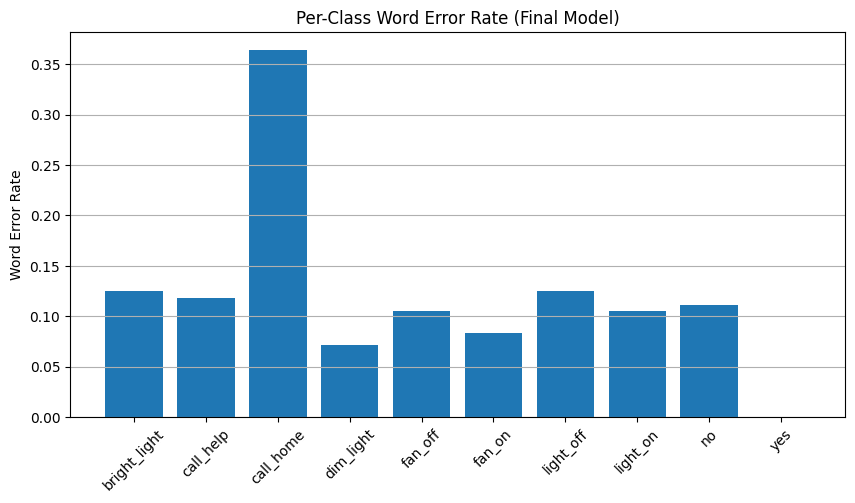

Overall Validation WER: 0.1181


In [ ]:
from collections import defaultdict
from jiwer import wer
import torch
import matplotlib.pyplot as plt

model = test_model
model.eval()

true_texts = []
pred_texts = []

for p in real_val_paths:

    true_label = get_label_from_path(p)
    audio = load_audio(p)

    x = torch.tensor(audio).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        if isinstance(outputs, dict):
            logits = outputs["logits"]
        else:
            logits = outputs

        pred_id = torch.argmax(logits, dim=1).item()

    pred_label = id2label[pred_id]

    true_texts.append(true_label)
    pred_texts.append(pred_label)

# ---- Compute per-class WER ----
class_wers = {}

for cmd in COMMANDS:
    true_cmd = []
    pred_cmd = []

    for t, p in zip(true_texts, pred_texts):
        if t == cmd:
            true_cmd.append(t)
            pred_cmd.append(p)

    if len(true_cmd) > 0:
        class_wers[cmd] = wer(true_cmd, pred_cmd)

# ---- Plot ----
plt.figure(figsize=(10,5))
plt.bar(class_wers.keys(), class_wers.values())
plt.xticks(rotation=45)
plt.ylabel("Word Error Rate")
plt.title("Per-Class Word Error Rate (Final Model)")
plt.grid(axis="y")
plt.show()

# Print overall WER
overall_wer = wer(true_texts, pred_texts)
print("Overall Validation WER:", round(overall_wer,4))

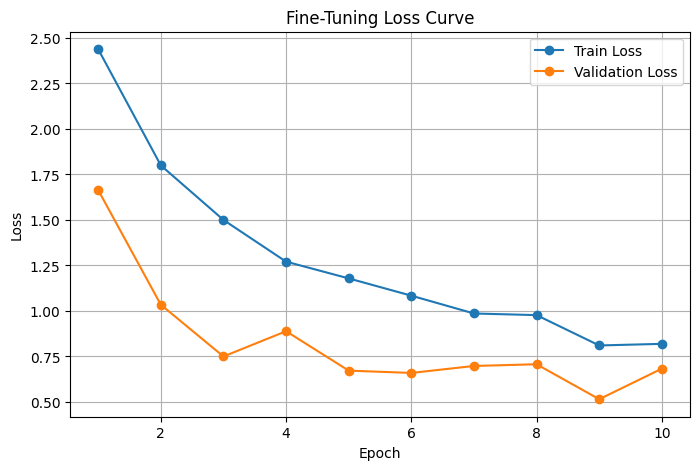

In [87]:
import matplotlib.pyplot as plt

train_losses = [2.4383, 1.7998, 1.5002, 1.2710, 1.1789,
                1.0840, 0.9861, 0.9772, 0.8104, 0.8193]

val_losses = [1.6643, 1.0341, 0.7499, 0.8887, 0.6721,
              0.6595, 0.6978, 0.7072, 0.5150, 0.6830]

epochs = range(1, 11)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import os
import librosa

DATA_DIR = REAL_DIR   # or your dataset folder

audio_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith(".wav")]

total_seconds = 0
speaker_ids = set()
durations = []

for path in audio_files:
    
    # load audio
    audio, sr = librosa.load(path, sr=None)
    
    duration = len(audio) / sr
    durations.append(duration)
    
    total_seconds += duration
    
    # extract speaker id from filename
    filename = os.path.basename(path)
    parts = filename.split("_")
    
    for p in parts:
        if p.startswith("p"):
            speaker_ids.add(p)

total_hours = total_seconds / 3600

print("Total audio files:", len(audio_files))
print("Number of speakers:", len(speaker_ids))
print("Speaker IDs:", sorted(speaker_ids))
print("Total duration (seconds):", round(total_seconds,2))
print("Total duration (hours):", round(total_hours,2))
print("Average duration per audio:", round(sum(durations)/len(durations),2),"seconds")

/Users/adithyanv/Documents/SpeakEasy/speakeasy_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total audio files: 720
Number of speakers: 20
Speaker IDs: ['p1', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19', 'p2', 'p3', 'p3 ', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9']
Total duration (seconds): 1064.13
Total duration (hours): 0.3
Average duration per audio: 1.48 seconds
